In [ ]:
import numpy as np
import pandas as pd
import time

import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt


**1.   Data reading**

In [ ]:
df = pd.read_csv('Timeseries_32.207_-6.532_SA3_300kWp_crystSi_18_33deg_0deg_2010_2023.csv',
                 skiprows=10,
                 nrows=122723)
df = df.iloc[96432:].copy()
print(f"Forme du tableau : {df.shape}")
print(df.head())
# print("Colonnes détectées :", df.columns.tolist())
# print(df.head())
print(df.tail())


Forme du tableau : (26280, 9)
                time    P  Gb(i)  Gd(i)  Gr(i)  H_sun   T2m  WS10m  Int
96432  20210101:0009  0.0    0.0    0.0    0.0    0.0  4.82   0.90  0.0
96433  20210101:0109  0.0    0.0    0.0    0.0    0.0  3.20   1.17  0.0
96434  20210101:0209  0.0    0.0    0.0    0.0    0.0  2.97   1.10  0.0
96435  20210101:0309  0.0    0.0    0.0    0.0    0.0  3.63   0.83  0.0
96436  20210101:0409  0.0    0.0    0.0    0.0    0.0  3.59   0.76  0.0
                 time    P  Gb(i)  Gd(i)  Gr(i)  H_sun    T2m  WS10m  Int
122707  20231231:1909  0.0    0.0    0.0    0.0    0.0  14.08   0.97  0.0
122708  20231231:2009  0.0    0.0    0.0    0.0    0.0  12.60   1.17  0.0
122709  20231231:2109  0.0    0.0    0.0    0.0    0.0  10.61   1.45  0.0
122710  20231231:2209  0.0    0.0    0.0    0.0    0.0   8.63   1.72  0.0
122711  20231231:2309  0.0    0.0    0.0    0.0    0.0   6.96   1.86  0.0




2.   **Feature Engineering**



*   Temporal cycling







In [ ]:
# datetime
df['time'] = pd.to_datetime(df['time'], format='%Y%m%d:%H%M')# Convertir en format datetime
df['hour'] = df['time'].dt.hour  # Extraire l'heure (0 à 23)
df['month'] = df['time'].dt.month  # Extraire le mois (1 à 12) pour la saisonnalité
# Sélection des colonnes pour le modèle
features = ['P', 'Gb(i)', 'Gd(i)', 'Gr(i)', 'H_sun', 'T2m', 'WS10m', 'hour', 'month']
data = df[features].values
# Cyclage de l'Heure (période de 24h)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
# Cyclage du Mois (période de 12 mois)
df['month_sin'] = np.sin(2 * np.pi * (df['month']-1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df['month']-1) / 12)

# We define the columns that we want to keep for the model
# Note: We keep Gb(i) and Gd(i) because they are crucial for the solar
features_finales = [
    'P', 'Gb(i)', 'Gd(i)', 'Gr(i)', 'H_sun', 'T2m', 'WS10m',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]

# We create the working dataset
df_final = df[features_finales]

print("Aperçu du dataset final (9 colonnes) :")
print(df_final.head())


Aperçu du dataset final (9 colonnes) :
         P  Gb(i)  Gd(i)  Gr(i)  H_sun   T2m  WS10m  hour_sin  hour_cos  \
96432  0.0    0.0    0.0    0.0    0.0  4.82   0.90  0.000000  1.000000   
96433  0.0    0.0    0.0    0.0    0.0  3.20   1.17  0.258819  0.965926   
96434  0.0    0.0    0.0    0.0    0.0  2.97   1.10  0.500000  0.866025   
96435  0.0    0.0    0.0    0.0    0.0  3.63   0.83  0.707107  0.707107   
96436  0.0    0.0    0.0    0.0    0.0  3.59   0.76  0.866025  0.500000   

       month_sin  month_cos  
96432        0.0        1.0  
96433        0.0        1.0  
96434        0.0        1.0  
96435        0.0        1.0  
96436        0.0        1.0  


--- Corrélations des variables avec la Puissance (P) ---
P            1.000000
Gb(i)        0.977853
Gr(i)        0.965264
H_sun        0.883983
Gd(i)        0.782969
T2m          0.421169
WS10m        0.194644
month_sin    0.034861
hour_sin    -0.026138
month_cos   -0.072855
hour_cos    -0.800011
Name: P, dtype: float64


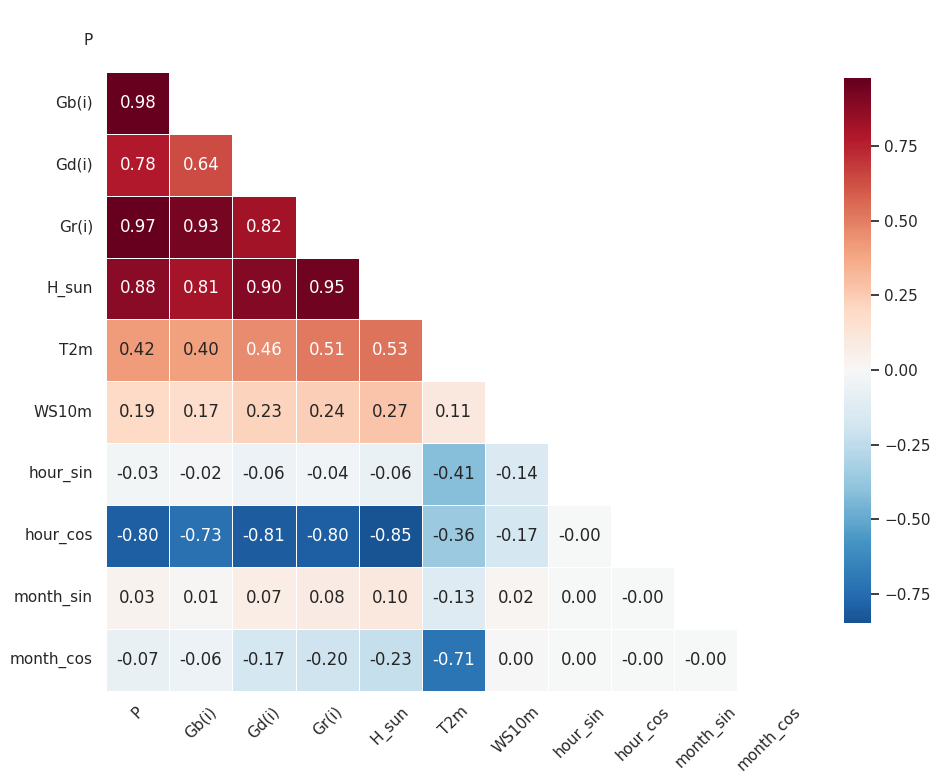

In [ ]:
# 1. Sélection des variables pour l'analyse
# Assure-toi que ces colonnes existent exactement sous ces noms dans ton DataFrame 'df'
# cols_to_corr = ['P', 'Gb(i)', 'Gd(i)', 'T2m', 'WS10m',
#                 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

# 2. Calcul de la matrice de corrélation de Pearson
corr_matrix = df_final.corr()

# 3. Configuration visuelle
plt.figure(figsize=(10, 8))
sns.set(style="white")

# Création d'un masque pour ne voir que la partie inférieure (évite la répétition)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Dessin du Heatmap
heatmap = sns.heatmap(corr_matrix,
                      mask=mask,
                      annot=True,           # Affiche les valeurs numériques
                      fmt=".2f",            # 2 décimales
                      cmap='RdBu_r',        # Rouge pour positif, Bleu pour négatif
                      center=0,
                      linewidths=.5,
                      cbar_kws={"shrink": .8})

correlation_with_P = corr_matrix['P'].sort_values(ascending=False)

print("--- Corrélations des variables avec la Puissance (P) ---")
print(correlation_with_P)

# plt.title('Pearson Correlation Matrix - Afourer Site', fontsize=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# 5. Sauvegarde pour ton article
plt.tight_layout()
plt.savefig('correlation_matrix_afourer.png', dpi=300)
plt.show()

In [ ]:
# 1. Calcul de la matrice
full_corr_matrix = df[['P', 'Gb(i)', 'Gd(i)', 'Gr(i)', 'T2m', 'WS10m', 'H_sun',
                       'hour_sin', 'hour_cos', 'month_sin', 'month_cos']].corr()

# 2. Affichage complet pour me le transmettre
print("--- MATRICE DE CORRÉLATION BRUTE ---")
print(full_corr_matrix.round(4)) # Arrondi à 4 décimales pour la précision scientifique

--- MATRICE DE CORRÉLATION BRUTE ---
                P   Gb(i)   Gd(i)   Gr(i)     T2m   WS10m   H_sun  hour_sin  \
P          1.0000  0.9779  0.7830  0.9653  0.4212  0.1946  0.8840   -0.0261   
Gb(i)      0.9779  1.0000  0.6412  0.9327  0.3962  0.1736  0.8104   -0.0169   
Gd(i)      0.7830  0.6412  1.0000  0.8195  0.4620  0.2287  0.8955   -0.0621   
Gr(i)      0.9653  0.9327  0.8195  1.0000  0.5129  0.2414  0.9451   -0.0354   
T2m        0.4212  0.3962  0.4620  0.5129  1.0000  0.1080  0.5296   -0.4145   
WS10m      0.1946  0.1736  0.2287  0.2414  0.1080  1.0000  0.2748   -0.1374   
H_sun      0.8840  0.8104  0.8955  0.9451  0.5296  0.2748  1.0000   -0.0634   
hour_sin  -0.0261 -0.0169 -0.0621 -0.0354 -0.4145 -0.1374 -0.0634    1.0000   
hour_cos  -0.8000 -0.7272 -0.8084 -0.8013 -0.3606 -0.1747 -0.8460   -0.0000   
month_sin  0.0349  0.0133  0.0699  0.0828 -0.1252  0.0163  0.1039    0.0000   
month_cos -0.0729 -0.0554 -0.1727 -0.2045 -0.7146  0.0033 -0.2276    0.0000   

           hou

In [ ]:
full_corr_matrix['H_sun']

,H_sun
P,0.883983
Gb(i),0.810359
Gd(i),0.895533
Gr(i),0.945136
T2m,0.529613
WS10m,0.274780
H_sun,1.000000
hour_sin,-0.063393
hour_cos,-0.846043
month_sin,0.103942


visualisation de la Target

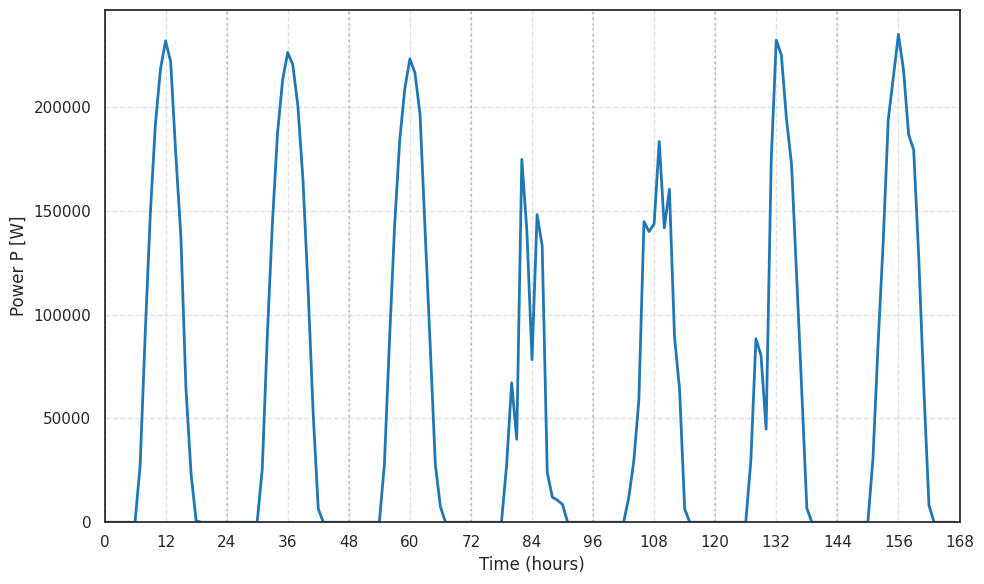

In [ ]:
# 1. Sélection de la période
start_hour = 2400
df_week = df.iloc[start_hour:start_hour+168].copy()

# 2. On crée un vecteur d'heures relatif (0, 1, 2, ..., 167)
heures_relatives = range(len(df_week))

# 3. Création du graphique
plt.figure(figsize=(10, 6))
plt.plot(heures_relatives, df_week['P'], color='#1f77b4', linewidth=2, label='Puissance PV (W)')

# 4. GESTION DE LA LISIBILITÉ : On affiche un repère toutes les 24 heures
# Cela correspond à chaque nouveau jour
plt.xticks(range(0, 169, 12))

# 5. Esthétique
# plt.title('Profil de production horaire sur une semaine (Site d\'Afourer)', fontsize=15)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Power P [W]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 168)
plt.ylim(bottom=0)

# Optionnel : ajouter des lignes verticales pour séparer visuellement les jours
for h in range(0, 169, 24):
    plt.axvline(x=h, color='gray', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('graphe_hebdomadaire_heures.png', dpi=300)
plt.show()

In [ ]:

np.max(df_final['P'])